# Class Scheduling with Genetic Algorithm

Notebook này tập trung vào phần triển khai và chạy thử Genetic Algorithm cho bài toán lập thời khóa biểu. Nội dung chính gồm: sinh dữ liệu đầu vào, cài đặt GA, chạy thuật toán, theo dõi penalty/fitness và xuất thời khóa biểu cuối cùng.


In [1]:
import random
import copy
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

## 1. Sinh dữ liệu đầu vào

Cell dưới đây tạo dữ liệu mô phỏng cho bài toán: danh sách course, section, professor, room, kích thước phòng, kích thước lớp và professor phụ trách từng course. Dữ liệu được sinh bằng seed cố định để kết quả có thể chạy lại giống nhau.


In [2]:
# Problem parameters
NUM_COURSES = 15
NUM_SECTIONS = 10
NUM_PROFESSORS = 10
NUM_DAYS = 5        # 0..4 tương ứng Mon..Fri
NUM_TIMESLOTS = 6   # 0..5
NUM_ROOMS = 30
SESSIONS_PER_WEEK = 2

DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri"]
TIMESLOTS = [f"Slot {i+1}" for i in range(NUM_TIMESLOTS)]

courses = list(range(1, NUM_COURSES + 1))
professors = list(range(1, NUM_PROFESSORS + 1))
rooms = list(range(1, NUM_ROOMS + 1))

# Room size: 0 = Small, 1 = Large
room_size = {room: random.choice([0, 1]) for room in rooms}

# Tạo 10 sections. Course có thể bị lặp lại theo đúng mô tả đề bài.
sections = list(range(1, NUM_SECTIONS + 1))
section_course = {section: random.randint(1, NUM_COURSES) for section in sections}

# Class registration size: 0 = Small, 1 = Large
section_size = {section: random.choice([0, 1]) for section in sections}

# Gán professor cho từng course, đồng thời cố gắng không để professor nào quá 3 courses lúc khởi tạo.
course_professor = {}
prof_load = Counter()
for course in courses:
    candidates = [p for p in professors if prof_load[p] < 3]
    if not candidates:
        candidates = professors
    p = random.choice(candidates)
    course_professor[course] = p
    prof_load[p] += 1

print("Section -> Course:", section_course)
print("Section size:", section_size)
print("Course -> Professor:", course_professor)
print("Professor load:", dict(prof_load))
print("Number of large rooms:", sum(room_size.values()), "/", NUM_ROOMS)

Section -> Course: {1: 7, 2: 2, 3: 6, 4: 14, 5: 6, 6: 10, 7: 5, 8: 13, 9: 1, 10: 12}
Section size: {1: 1, 2: 0, 3: 1, 4: 0, 5: 1, 6: 1, 7: 0, 8: 0, 9: 0, 10: 0}
Course -> Professor: {1: 5, 2: 2, 3: 4, 4: 2, 5: 7, 6: 5, 7: 8, 8: 6, 9: 3, 10: 6, 11: 6, 12: 4, 13: 5, 14: 2, 15: 8}
Professor load: {5: 3, 2: 3, 4: 2, 7: 1, 8: 2, 6: 3, 3: 1}
Number of large rooms: 9 / 30


## 2. Biểu diễn lịch học

Mỗi cá thể trong GA là một lịch học gồm nhiều gene. Mỗi gene tương ứng với một buổi học của một section và lưu các thông tin: section, course, professor, day, timeslot và room.


In [3]:
def random_gene(section, session_no):
    """Tạo một gene ngẫu nhiên cho một buổi học của section."""
    course = section_course[section]
    professor = course_professor[course]
    return {
        "section": section,
        "course": course,
        "professor": professor,
        "day": random.randint(0, NUM_DAYS - 1),
        "timeslot": random.randint(0, NUM_TIMESLOTS - 1),
        "room": random.choice(rooms),
        "session_no": session_no,
    }


def create_individual():
    """Tạo một thời khóa biểu ngẫu nhiên."""
    individual = []
    for section in sections:
        for session_no in range(1, SESSIONS_PER_WEEK + 1):
            individual.append(random_gene(section, session_no))
    return individual


def create_population(pop_size):
    return [create_individual() for _ in range(pop_size)]

sample = create_individual()
pd.DataFrame(sample).head()

,section,course,professor,day,timeslot,room,session_no
0,1,7,8,1,4,24,1
1,1,7,8,1,1,15,2
2,2,2,2,3,2,30,1
3,2,2,2,4,1,22,2
4,3,6,5,2,0,8,1


## 3. Fitness và penalty

Hàm fitness được tính từ tổng penalty. Penalty tăng khi lịch vi phạm ràng buộc như trùng lịch professor, trùng phòng, trùng section, phòng nhỏ xếp cho lớp lớn hoặc hai buổi của cùng section quá gần nhau.


In [4]:
PENALTY_SAME_OR_ADJACENT_DAY = 20
PENALTY_ROOM_SIZE = 15
PENALTY_PROF_CONFLICT = 25
PENALTY_PROF_OVERLOAD = 30
PENALTY_SECTION_CONFLICT = 25
PENALTY_ROOM_CONFLICT = 25


def calculate_penalty(individual, return_details=False):
    penalty = 0
    details = defaultdict(int)

    # Constraint 1: mỗi section có 2 buổi không được cùng ngày hoặc ngày liền kề
    by_section = defaultdict(list)
    for gene in individual:
        by_section[gene["section"]].append(gene)

    for section, genes in by_section.items():
        if len(genes) >= 2:
            days = sorted([g["day"] for g in genes])
            if days[0] == days[1] or abs(days[0] - days[1]) == 1:
                penalty += PENALTY_SAME_OR_ADJACENT_DAY
                details["same_or_adjacent_day"] += 1

    # Constraint 2: room size phù hợp class registration size
    for gene in individual:
        sec_size = section_size[gene["section"]]
        r_size = room_size[gene["room"]]
        # room nhỏ 0 chỉ dùng cho lớp nhỏ 0; room lớn 1 dùng được cả hai
        if sec_size == 1 and r_size == 0:
            penalty += PENALTY_ROOM_SIZE
            details["room_size_conflict"] += 1

    # Constraint 3: professor không dạy 2 course cùng thời điểm
    prof_time = defaultdict(list)
    for gene in individual:
        key = (gene["professor"], gene["day"], gene["timeslot"])
        prof_time[key].append(gene)

    for key, genes in prof_time.items():
        if len(genes) > 1:
            conflicts = len(genes) - 1
            penalty += conflicts * PENALTY_PROF_CONFLICT
            details["professor_time_conflict"] += conflicts

    # Constraint 4: professor không dạy quá 3 courses
    prof_courses = defaultdict(set)
    for course, professor in course_professor.items():
        prof_courses[professor].add(course)

    for professor, assigned_courses in prof_courses.items():
        if len(assigned_courses) > 3:
            overload = len(assigned_courses) - 3
            penalty += overload * PENALTY_PROF_OVERLOAD
            details["professor_overload"] += overload

    # Constraint 5: một section không được xếp 2 phòng cùng lúc
    section_time = defaultdict(list)
    for gene in individual:
        key = (gene["section"], gene["day"], gene["timeslot"])
        section_time[key].append(gene)

    for key, genes in section_time.items():
        if len(genes) > 1:
            conflicts = len(genes) - 1
            penalty += conflicts * PENALTY_SECTION_CONFLICT
            details["section_time_conflict"] += conflicts

    # Constraint 6: một room không được dùng cho 2 sections cùng lúc
    room_time = defaultdict(list)
    for gene in individual:
        key = (gene["room"], gene["day"], gene["timeslot"])
        room_time[key].append(gene)

    for key, genes in room_time.items():
        if len(genes) > 1:
            conflicts = len(genes) - 1
            penalty += conflicts * PENALTY_ROOM_CONFLICT
            details["room_time_conflict"] += conflicts

    if return_details:
        return penalty, dict(details)
    return penalty


def fitness(individual):
    return 1 / (1 + calculate_penalty(individual))

penalty, details = calculate_penalty(sample, return_details=True)
print("Sample penalty:", penalty)
print("Sample fitness:", fitness(sample))
print("Details:", details)

Sample penalty: 185
Sample fitness: 0.005376344086021506
Details: {'same_or_adjacent_day': 4, 'room_size_conflict': 7}


## 4. Tournament selection

Cell này cài đặt tournament selection để chọn parent. Trong mỗi tournament, một nhóm cá thể được chọn ngẫu nhiên và cá thể có fitness tốt nhất sẽ được dùng để lai ghép.


In [5]:
def tournament_selection(population, k=3):
    candidates = random.sample(population, k)
    candidates.sort(key=fitness, reverse=True)
    return copy.deepcopy(candidates[0])

## 5. Crossover

Cell này cài đặt one-point crossover. Hai parent được cắt tại một vị trí ngẫu nhiên và trao đổi một phần chromosome để tạo ra hai cá thể con.


In [6]:
def crossover(parent1, parent2, crossover_rate=0.9):
    if random.random() > crossover_rate:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)

    point = random.randint(1, len(parent1) - 2)
    child1 = copy.deepcopy(parent1[:point] + parent2[point:])
    child2 = copy.deepcopy(parent2[:point] + parent1[point:])

    return child1, child2

## 6. Mutation

Cell này cài đặt mutation. Một số gene được thay đổi ngẫu nhiên ở day, timeslot hoặc room để tạo thêm đa dạng cho quần thể.


In [7]:
def mutate(individual, mutation_rate=0.1):
    mutated = copy.deepcopy(individual)
    for gene in mutated:
        if random.random() < mutation_rate:
            mutation_type = random.choice(["day", "timeslot", "room"])
            if mutation_type == "day":
                gene["day"] = random.randint(0, NUM_DAYS - 1)
            elif mutation_type == "timeslot":
                gene["timeslot"] = random.randint(0, NUM_TIMESLOTS - 1)
            elif mutation_type == "room":
                gene["room"] = random.choice(rooms)
    return mutated

## 7. Chạy Genetic Algorithm

Cell này chạy vòng lặp GA chính: khởi tạo population, đánh giá fitness, chọn lọc, crossover, mutation và elitism. Quá trình chạy lưu lại penalty/fitness tốt nhất theo từng generation.


In [8]:
def run_ga(
    pop_size=100,
    generations=300,
    crossover_rate=0.9,
    mutation_rate=0.1,
    tournament_k=3,
    elitism_count=2,
):
    population = create_population(pop_size)

    best_individual = None
    best_fitness = -1
    best_penalty = float("inf")

    history = []

    for gen in range(generations):
        population.sort(key=fitness, reverse=True)

        current_best = population[0]
        current_penalty = calculate_penalty(current_best)
        current_fitness = fitness(current_best)

        if current_fitness > best_fitness:
            best_individual = copy.deepcopy(current_best)
            best_fitness = current_fitness
            best_penalty = current_penalty

        avg_penalty = sum(calculate_penalty(ind) for ind in population) / len(population)
        history.append({
            "generation": gen,
            "best_penalty": best_penalty,
            "current_best_penalty": current_penalty,
            "avg_penalty": avg_penalty,
            "best_fitness": best_fitness,
        })

        if best_penalty == 0:
            print(f"Found conflict-free schedule at generation {gen}")
            break

        new_population = [copy.deepcopy(ind) for ind in population[:elitism_count]]

        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, tournament_k)
            parent2 = tournament_selection(population, tournament_k)

            child1, child2 = crossover(parent1, parent2, crossover_rate)
            child1 = mutate(child1, mutation_rate)
            child2 = mutate(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < pop_size:
                new_population.append(child2)

        population = new_population

    return best_individual, pd.DataFrame(history)

best_schedule, history = run_ga(
    pop_size=150,
    generations=500,
    crossover_rate=0.9,
    mutation_rate=0.08,
    tournament_k=4,
    elitism_count=3,
)

print("Best penalty:", calculate_penalty(best_schedule))
print("Best fitness:", fitness(best_schedule))
print("Conflict details:", calculate_penalty(best_schedule, return_details=True)[1])
history.tail()

Found conflict-free schedule at generation 9
Best penalty: 0
Best fitness: 1.0
Conflict details: {}


,generation,best_penalty,current_best_penalty,avg_penalty,best_fitness
5,5,35,35,91.900000,0.027778
6,6,35,35,78.033333,0.027778
7,7,15,15,68.800000,0.062500
8,8,15,15,60.700000,0.062500
9,9,0,0,46.500000,1.000000


## 8. Biểu đồ penalty và fitness

Cell này vẽ biểu đồ theo dõi quá trình tiến hóa. Penalty giảm thể hiện lịch ít vi phạm hơn, còn fitness tăng thể hiện chất lượng lời giải tốt hơn.


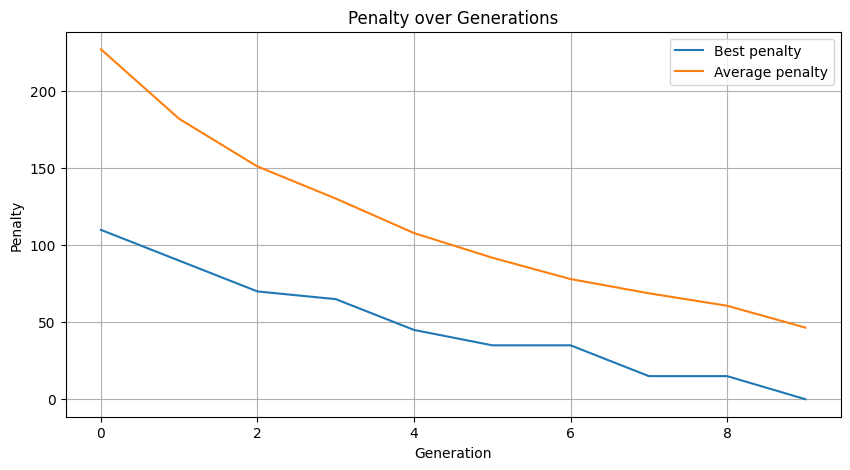

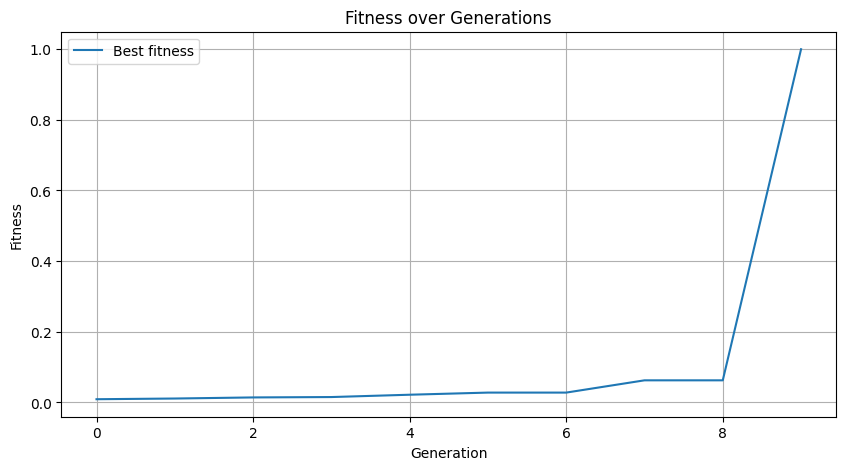

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history["generation"], history["best_penalty"], label="Best penalty")
plt.plot(history["generation"], history["avg_penalty"], label="Average penalty")
plt.xlabel("Generation")
plt.ylabel("Penalty")
plt.title("Penalty over Generations")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["generation"], history["best_fitness"], label="Best fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Fitness over Generations")
plt.legend()
plt.grid(True)
plt.show()

## 9. Bảng thời khóa biểu cuối cùng

Cell này chuyển cá thể tốt nhất thành bảng dữ liệu dễ đọc và lưu ra file `final_class_schedule.csv`.


In [10]:
def schedule_to_dataframe(schedule):
    rows = []
    for gene in schedule:
        rows.append({
            "Section": gene["section"],
            "Course": gene["course"],
            "Session": gene["session_no"],
            "Professor": gene["professor"],
            "Day": DAYS[gene["day"]],
            "Timeslot": TIMESLOTS[gene["timeslot"]],
            "Room": gene["room"],
            "Room Size": "Large" if room_size[gene["room"]] == 1 else "Small",
            "Class Size": "Large" if section_size[gene["section"]] == 1 else "Small",
        })
    df = pd.DataFrame(rows)
    day_order = {day: i for i, day in enumerate(DAYS)}
    slot_order = {slot: i for i, slot in enumerate(TIMESLOTS)}
    df["DayOrder"] = df["Day"].map(day_order)
    df["SlotOrder"] = df["Timeslot"].map(slot_order)
    df = df.sort_values(["DayOrder", "SlotOrder", "Room", "Section"]).drop(columns=["DayOrder", "SlotOrder"])
    return df.reset_index(drop=True)

final_df = schedule_to_dataframe(best_schedule)
final_df

,Section,Course,Session,Professor,Day,Timeslot,Room,Room Size,Class Size
0,8,13,1,5,Mon,Slot 1,8,Small,Small
1,7,5,2,7,Mon,Slot 1,10,Small,Small
2,4,14,1,2,Mon,Slot 1,13,Small,Small
3,9,1,2,5,Mon,Slot 2,10,Small,Small
4,2,2,1,2,Mon,Slot 2,14,Small,Small
5,10,12,1,4,Mon,Slot 5,1,Small,Small
6,5,6,2,5,Mon,Slot 6,28,Large,Large
7,3,6,1,5,Tue,Slot 3,3,Large,Large
8,6,10,1,6,Tue,Slot 4,24,Large,Large
9,1,7,1,8,Tue,Slot 4,25,Large,Large


In [ ]:
# Lưu kết quả ra CSV
final_df.to_csv("final_class_schedule.csv", index=False)
history.to_csv("ga_history.csv", index=False)

print("Saved final_class_schedule.csv and ga_history.csv")

Saved final_class_schedule.csv and ga_history.csv


## 10. Kiểm tra kết quả

Cell này in lại best penalty và thống kê nhanh các vi phạm còn lại trong lịch cuối cùng.


In [12]:
final_penalty, final_details = calculate_penalty(best_schedule, return_details=True)
print("Final penalty:", final_penalty)
print("Final conflict details:", final_details)

if final_penalty == 0:
    print("No conflicts found. This is a valid schedule according to the designed constraints.")
else:
    print("There are still some conflicts. Try increasing generations/pop_size or tuning mutation_rate.")

Final penalty: 0
Final conflict details: {}
No conflicts found. This is a valid schedule according to the designed constraints.


## 11. Kết quả lưu file

Sau khi chạy notebook, các file kết quả chính gồm `ga_history.csv` để theo dõi quá trình chạy GA và `final_class_schedule.csv` để xem thời khóa biểu cuối cùng.
